In [24]:
import os, json, math, random, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)

torch: 2.9.0+cu126
device: cuda


In [25]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [26]:
DATASET_ROOT = Path("/content/drive/MyDrive/unet_dataset_mt2023_v2/shards")  # <= seu caminho
assert DATASET_ROOT.exists(), f"não achei DATASET_ROOT: {DATASET_ROOT}"

RUN_NAME = "unet_mt2023_v2_run1"
OUT_RUN = Path("/content/drive/MyDrive/unet_runs") / RUN_NAME
OUT_RUN.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_RUN / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = OUT_RUN / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("OUT_RUN:", OUT_RUN)

DATASET_ROOT: /content/drive/MyDrive/unet_dataset_mt2023_v2/shards
OUT_RUN: /content/drive/MyDrive/unet_runs/unet_mt2023_v2_run1


In [27]:
# dados
IN_CH = 21
SCALE_U16 = 10000.0     # X veio de UInt16 * 10000 no GEE
IGNORE_VAL = 255

# treino
EPOCHS = 25
LR = 1e-3
WEIGHT_DECAY = 1e-5

# batch (CPU vs GPU)
BATCH_SIZE = 8 if device.type == "cuda" else 2
print("BATCH_SIZE:", BATCH_SIZE)

# threshold para métrica
PRED_THR = 0.5

BATCH_SIZE: 8


In [28]:
def list_npz(split):
    p = DATASET_ROOT / split
    assert p.exists(), f"não achei split: {p}"
    files = sorted(p.glob("*.npz"))
    assert len(files) > 0, f"split vazio: {p}"
    return files

train_shards = list_npz("train")
val_shards   = list_npz("val")
test_shards  = list_npz("test")

print("train shards:", len(train_shards), "| ex:", train_shards[0].name)
print("val   shards:", len(val_shards),   "| ex:", val_shards[0].name)
print("test  shards:", len(test_shards),  "| ex:", test_shards[0].name)

# conta patches por split (lendo só o shape do X em cada shard)
def count_patches(shards):
    total = 0
    for fp in tqdm(shards, desc="count patches", leave=False):
        with np.load(fp, allow_pickle=True) as z:
            X = z["X"]
            total += int(X.shape[0])
    return total

n_train = count_patches(train_shards)
n_val   = count_patches(val_shards)
n_test  = count_patches(test_shards)

print("patches train:", n_train)
print("patches val  :", n_val)
print("patches test :", n_test)

train_steps = math.ceil(n_train / BATCH_SIZE)
val_steps   = math.ceil(n_val   / BATCH_SIZE)
print("steps/epoch train:", train_steps, "| val:", val_steps)

train shards: 94 | ex: shard_0000.npz
val   shards: 19 | ex: shard_0000.npz
test  shards: 19 | ex: shard_0000.npz


patches train: 3000
patches val  : 600
patches test : 600
steps/epoch train: 375 | val: 75


In [29]:
from torch.utils.data import IterableDataset, DataLoader, get_worker_info

class ShardStreamDataset(IterableDataset):
    def __init__(self, shard_files, split, seed=42, shuffle_shards=True, shuffle_in_shard=True):
        self.shard_files = list(shard_files)
        self.split = split
        self.seed = int(seed)
        self.shuffle_shards = bool(shuffle_shards)
        self.shuffle_in_shard = bool(shuffle_in_shard)

    def __iter__(self):
        worker = get_worker_info()
        if worker is None:
            shard_list = self.shard_files
            base_seed = self.seed
        else:
            # divide shards entre workers para não duplicar dados
            shard_list = self.shard_files[worker.id::worker.num_workers]
            base_seed = self.seed + worker.id

        rng = np.random.default_rng(base_seed)

        shard_list = list(shard_list)
        if self.shuffle_shards:
            rng.shuffle(shard_list)

        for fp in shard_list:
            with np.load(fp, allow_pickle=True) as z:
                X = z["X"]  # (N,H,W,C) uint16
                Y = z["Y"]  # (N,H,W)   uint8

            idxs = np.arange(X.shape[0])
            if self.shuffle_in_shard:
                rng.shuffle(idxs)

            for i in idxs:
                xi = X[i].astype(np.float32) / SCALE_U16
                yi = Y[i].astype(np.uint8)

                # retorna SEM meta para evitar "too many values to unpack"
                yield {
                    "X": torch.from_numpy(xi).permute(2,0,1),  # (C,H,W)
                    "Y": torch.from_numpy(yi)                  # (H,W)
                }

# num_workers: use 0 se estiver dando instabilidade
NUM_WORKERS = 0 if device.type == "cpu" else 2
PIN_MEMORY = (device.type == "cuda")

train_ds = ShardStreamDataset(train_shards, "train", seed=SEED, shuffle_shards=True, shuffle_in_shard=True)
val_ds   = ShardStreamDataset(val_shards,   "val",   seed=SEED+1, shuffle_shards=False, shuffle_in_shard=False)
test_ds  = ShardStreamDataset(test_shards,  "test",  seed=SEED+2, shuffle_shards=False, shuffle_in_shard=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("loaders OK")

loaders OK


In [30]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=21, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool4 = nn.MaxPool2d(2)

        self.bott = ConvBlock(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = ConvBlock(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.head = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bott(self.pool4(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.head(d1)  # logits (B,1,H,W)

model = UNet(in_ch=IN_CH, base=32).to(device)
print("model OK")

model OK


In [31]:
# estimativa rápida de pos_weight a partir de alguns shards de treino
def estimate_pos_weight(shards, max_shards=10):
    pos = 0
    neg = 0
    for fp in shards[:max_shards]:
        with np.load(fp, allow_pickle=True) as z:
            Y = z["Y"]  # (N,H,W)
        valid = (Y != IGNORE_VAL)
        pos += int(((Y == 1) & valid).sum())
        neg += int(((Y == 0) & valid).sum())
    if pos == 0:
        return 1.0
    return float(neg / pos)

pos_weight_val = estimate_pos_weight(train_shards, max_shards=min(10, len(train_shards)))
print("estimated pos_weight:", pos_weight_val)

pos_weight = torch.tensor([pos_weight_val], device=device, dtype=torch.float32)
bce_raw = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

def masked_bce_loss(logits, Y):
    # logits: (B,1,H,W) ; Y: (B,H,W) uint8 com 0/1/255
    Yf = Y.float()
    valid = (Y != IGNORE_VAL)
    if valid.sum().item() == 0:
        return torch.tensor(0.0, device=logits.device)

    logits2 = logits[:,0,:,:]
    loss = bce_raw(logits2, Yf)  # (B,H,W)
    loss = loss[valid].mean()
    return loss

@torch.no_grad()
def batch_metrics(logits, Y):
    # métricas só em pixels válidos (Y != 255)
    prob = torch.sigmoid(logits[:,0,:,:])
    pred = (prob >= PRED_THR).to(torch.uint8)

    valid = (Y != IGNORE_VAL)
    if valid.sum().item() == 0:
        return {"iou": 0.0, "f1": 0.0, "prec": 0.0, "rec": 0.0}

    yv = Y[valid]
    pv = pred[valid]

    tp = int(((pv==1) & (yv==1)).sum())
    fp = int(((pv==1) & (yv==0)).sum())
    fn = int(((pv==0) & (yv==1)).sum())

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2*prec*rec / (prec + rec + 1e-9)
    iou  = tp / (tp + fp + fn + 1e-9)
    return {"iou": float(iou), "f1": float(f1), "prec": float(prec), "rec": float(rec)}

estimated pos_weight: 0.8296675778886083


In [32]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def save_ckpt(path, epoch, best_val, extra=None):
    d = {
        "epoch": epoch,
        "best_val": float(best_val),
        "model": model.state_dict(),
        "optim": optimizer.state_dict(),
    }
    if extra:
        d.update(extra)
    torch.save(d, path)

def load_ckpt(path):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optim"])
    return int(ckpt["epoch"]), float(ckpt["best_val"])

CKPT_LAST = CKPT_DIR / "last.pt"
CKPT_BEST = CKPT_DIR / "best.pt"

start_epoch = 0
best_val = 1e9

if CKPT_LAST.exists():
    start_epoch, best_val = load_ckpt(CKPT_LAST)
    start_epoch += 1
    print("RESUME -> epoch", start_epoch, "best_val", best_val)
else:
    print("START FROM SCRATCH")

START FROM SCRATCH


In [33]:
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
AMP = (device.type=="cuda")

for epoch in range(start_epoch, EPOCHS):
    # --- TRAIN ---
    model.train()
    tr_loss = 0.0
    tr_steps = 0
    tr_iou = tr_f1 = 0.0

    pbar = tqdm(train_loader, total=train_steps, desc=f"train e{epoch+1}/{EPOCHS}")
    for step, batch in enumerate(pbar, start=1):
        X = batch["X"].to(device, non_blocking=True)          # (B,C,H,W)
        Y = batch["Y"].to(device, non_blocking=True)          # (B,H,W)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            logits = model(X)                                 # (B,1,H,W)
            loss = masked_bce_loss(logits, Y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        m = batch_metrics(logits.detach(), Y)
        tr_loss += float(loss.item())
        tr_iou  += m["iou"]
        tr_f1   += m["f1"]
        tr_steps += 1

        pbar.set_postfix({
            "loss": f"{tr_loss/max(1,tr_steps):.4f}",
            "iou":  f"{tr_iou/max(1,tr_steps):.3f}",
            "f1":   f"{tr_f1/max(1,tr_steps):.3f}",
            "lr":   f"{optimizer.param_groups[0]['lr']:.1e}"
        })

        # checkpoint “anti-desconexão” a cada ~200 steps
        if step % 200 == 0:
            save_ckpt(CKPT_LAST, epoch, best_val)

        if step >= train_steps:
            break

    tr_loss /= max(1, tr_steps)
    tr_iou  /= max(1, tr_steps)
    tr_f1   /= max(1, tr_steps)

    # --- VAL ---
    model.eval()
    va_loss = 0.0
    va_steps = 0
    va_iou = va_f1 = 0.0

    with torch.no_grad():
        vbar = tqdm(val_loader, total=val_steps, desc=f"val e{epoch+1}/{EPOCHS}", leave=False)
        for step, batch in enumerate(vbar, start=1):
            X = batch["X"].to(device, non_blocking=True)
            Y = batch["Y"].to(device, non_blocking=True)

            logits = model(X)
            loss = masked_bce_loss(logits, Y)

            m = batch_metrics(logits, Y)
            va_loss += float(loss.item())
            va_iou  += m["iou"]
            va_f1   += m["f1"]
            va_steps += 1

            if step >= val_steps:
                break

    va_loss /= max(1, va_steps)
    va_iou  /= max(1, va_steps)
    va_f1   /= max(1, va_steps)

    scheduler.step(va_loss)

    print(f"[epoch {epoch+1}] train loss={tr_loss:.4f} iou={tr_iou:.3f} f1={tr_f1:.3f} | val loss={va_loss:.4f} iou={va_iou:.3f} f1={va_f1:.3f}")

    # salva last sempre
    save_ckpt(CKPT_LAST, epoch, best_val, extra={"val_loss": va_loss})

    # salva best
    if va_loss < best_val:
        best_val = va_loss
        save_ckpt(CKPT_BEST, epoch, best_val, extra={"val_loss": va_loss})
        print("✅ new BEST:", best_val)

    # log por epoch
    log_line = {"epoch": epoch+1, "train_loss": tr_loss, "val_loss": va_loss, "train_iou": tr_iou, "val_iou": va_iou, "train_f1": tr_f1, "val_f1": va_f1, "lr": optimizer.param_groups[0]["lr"]}
    (LOG_DIR / "history.jsonl").open("a", encoding="utf-8").write(json.dumps(log_line)+"\n")

/tmp/ipython-input-4151844373.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
train e1/25:   0%|          | 0/375 [00:00<?, ?it/s]/tmp/ipython-input-4151844373.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):
train e1/25: 100%|█████████▉| 374/375 [01:46<00:00,  3.50it/s, loss=0.2384, iou=0.663, f1=0.714, lr=1.0e-03]


[epoch 1] train loss=0.2384 iou=0.663 f1=0.714 | val loss=0.1206 iou=0.766 f1=0.793
✅ new BEST: 0.12055334063867727


train e2/25: 100%|█████████▉| 374/375 [01:50<00:00,  3.37it/s, loss=0.1594, iou=0.697, f1=0.738, lr=1.0e-03]


[epoch 2] train loss=0.1594 iou=0.697 f1=0.738 | val loss=0.0736 iou=0.788 f1=0.805
✅ new BEST: 0.07358060589681069


train e3/25: 100%|█████████▉| 374/375 [01:52<00:00,  3.31it/s, loss=0.1182, iou=0.721, f1=0.755, lr=1.0e-03]


...

[epoch 23] train loss=0.0019 iou=0.802 f1=0.802 | val loss=0.0633 iou=0.789 f1=0.806


train e24/25: 100%|█████████▉| 374/375 [01:52<00:00,  3.34it/s, loss=0.0017, iou=0.802, f1=0.802, lr=1.6e-05]


[epoch 24] train loss=0.0017 iou=0.802 f1=0.802 | val loss=0.0636 iou=0.790 f1=0.807


train e25/25: 100%|█████████▉| 374/375 [01:53<00:00,  3.30it/s, loss=0.0017, iou=0.802, f1=0.802, lr=1.6e-05]


[epoch 25] train loss=0.0017 iou=0.802 f1=0.802 | val loss=0.0646 iou=0.790 f1=0.807


In [34]:
# carrega o melhor
if CKPT_BEST.exists():
    epoch_best, best_val_loaded = load_ckpt(CKPT_BEST)
    print("loaded BEST epoch:", epoch_best, "best_val:", best_val_loaded)

model.eval()
te_loss = 0.0
te_steps = 0
te_iou = te_f1 = te_prec = te_rec = 0.0

test_steps = math.ceil(n_test / BATCH_SIZE)

with torch.no_grad():
    tbar = tqdm(test_loader, total=test_steps, desc="test")
    for step, batch in enumerate(tbar, start=1):
        X = batch["X"].to(device, non_blocking=True)
        Y = batch["Y"].to(device, non_blocking=True)

        logits = model(X)
        loss = masked_bce_loss(logits, Y)
        m = batch_metrics(logits, Y)

        te_loss += float(loss.item())
        te_iou  += m["iou"]
        te_f1   += m["f1"]
        te_prec += m["prec"]
        te_rec  += m["rec"]
        te_steps += 1

        if step >= test_steps:
            break

te_loss /= max(1, te_steps)
te_iou  /= max(1, te_steps)
te_f1   /= max(1, te_steps)
te_prec /= max(1, te_steps)
te_rec  /= max(1, te_steps)

print(f"TEST: loss={te_loss:.4f} iou={te_iou:.3f} f1={te_f1:.3f} prec={te_prec:.3f} rec={te_rec:.3f}")

loaded BEST epoch: 7 best_val: 0.05278628298624729


test:  99%|█████████▊| 74/75 [00:21<00:00,  3.37it/s]

TEST: loss=0.0456 iou=0.731 f1=0.738 prec=0.741 rec=0.737


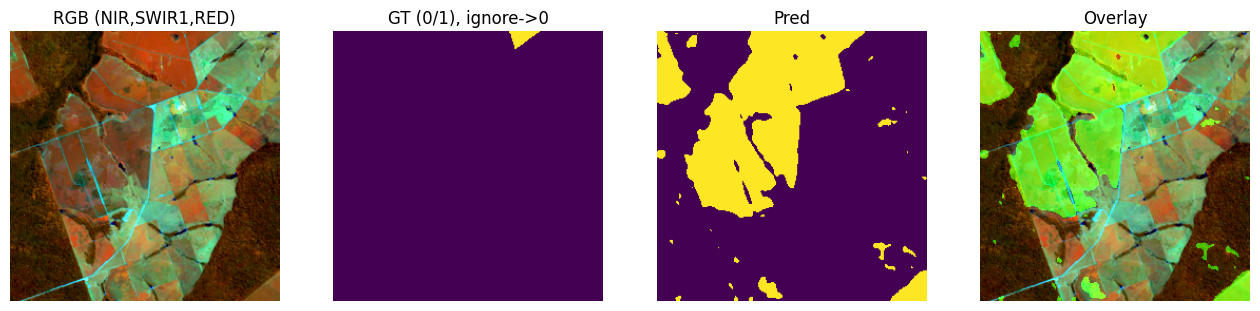

In [35]:
import matplotlib.pyplot as plt

# índices (ordem padrão 21 bandas)
IDX = {
    "RED_median": 6,
    "NIR_median": 9,
    "SWIR1_median": 12
}

def show_sample_from_split(split="val"):
    # pega um shard e um batch
    shards = {"train": train_shards, "val": val_shards, "test": test_shards}[split]
    fp = shards[0]
    with np.load(fp, allow_pickle=True) as z:
        X = z["X"][0].astype(np.float32) / SCALE_U16  # (H,W,C)
        Y = z["Y"][0].astype(np.uint8)                # (H,W)

    rgb = np.stack([X[:,:,IDX["NIR_median"]], X[:,:,IDX["SWIR1_median"]], X[:,:,IDX["RED_median"]]], axis=-1)
    rgb = np.clip(rgb, 0, 1)

    # pred
    model.eval()
    with torch.no_grad():
        xt = torch.from_numpy(X).permute(2,0,1).unsqueeze(0).to(device)
        logits = model(xt)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred = (prob >= PRED_THR).astype(np.uint8)

    valid = (Y != IGNORE_VAL)
    y_show = Y.copy()
    y_show[~valid] = 0

    plt.figure(figsize=(16,4))
    plt.subplot(1,4,1); plt.title("RGB (NIR,SWIR1,RED)"); plt.imshow(rgb); plt.axis("off")
    plt.subplot(1,4,2); plt.title("GT (0/1), ignore->0"); plt.imshow(y_show, vmin=0, vmax=1); plt.axis("off")
    plt.subplot(1,4,3); plt.title("Pred"); plt.imshow(pred, vmin=0, vmax=1); plt.axis("off")

    ov = rgb.copy()
    ov[:,:,1] = np.clip(ov[:,:,1] + 0.6*(pred==1), 0, 1)  # realce verde
    plt.subplot(1,4,4); plt.title("Overlay"); plt.imshow(ov); plt.axis("off")
    plt.show()

show_sample_from_split("val")